# 03 — RGC Cluster Characterization, Stability, and Morphology Review

This notebook characterizes RGC image clusters using analyses beyond simple cluster-count comparison.

It assumes Notebook 02 already created:

- `../outputs/rgc_image_analysis/rgc_cluster_assignments.csv`
- `../outputs/rgc_image_analysis/rgc_resnet18_embeddings.csv`

This notebook asks:

1. Are clusters visually/morphologically different?
2. Are clusters well separated in CNN/PCA feature space?
3. Which images are most representative of each cluster?
4. Are KMeans clusters stable across random initializations?
5. Which interpretable image features help distinguish clusters?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    adjusted_rand_score
)
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

try:
    from skimage.filters import threshold_otsu
    from skimage.measure import label, regionprops
    from skimage.morphology import skeletonize, remove_small_objects
    SKIMAGE_AVAILABLE = True
except ImportError:
    SKIMAGE_AVAILABLE = False

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

In [2]:
# Paths

data_dir = Path("../data/cropped")

output_dir = Path("../outputs/rgc_image_analysis")
fig_dir = output_dir / "figures"
review_dir = output_dir / "cluster_review"

fig_dir.mkdir(parents=True, exist_ok=True)
review_dir.mkdir(parents=True, exist_ok=True)

assignments_path = output_dir / "rgc_cluster_assignments.csv"
embeddings_path = output_dir / "rgc_resnet18_embeddings.csv"

assignments = pd.read_csv(assignments_path)
embeddings_df = pd.read_csv(embeddings_path)

display(assignments.head())
display(embeddings_df.head())

print("Assignments:", assignments.shape)
print("Embeddings:", embeddings_df.shape)

,image_index,filename,kmeans_cluster,hierarchical_cluster
0,0,cropped0.tif,2,1
1,1,cropped1.tif,1,3
2,2,cropped10.tif,1,3
3,3,cropped11.tif,2,1
4,4,cropped12.tif,2,1


,filename,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511
0,cropped0.tif,0.073215,0.105922,0.000000,0.100159,0.162834,0.005846,0.132512,0.104217,0.457121,0.040562,0.066822,0.195931,0.010781,0.608554,0.035006,0.149179,0.000000,0.028462,0.436826,0.324956,0.097127,0.067308,0.011614,0.198564,0.143741,0.061214,0.001731,0.140818,0.000000,0.189425,0.233931,0.022299,0.189681,0.003772,0.026788,0.276662,0.004156,0.074964,0.029493,0.000000,0.006400,0.000000,0.034805,0.268721,0.036252,0.023519,0.233775,0.013192,0.000000,0.339112,0.502807,0.124392,0.013595,0.480306,2.921835,0.082452,0.386178,0.047851,0.041763,0.691310,0.076632,0.037175,0.214812,0.000000,0.551156,0.010876,0.251945,0.033046,0.365441,0.166702,0.005288,0.225185,0.226746,0.000000,0.164457,0.148557,0.021172,0.000000,0.198238,0.094568,0.140919,3.339190,0.030332,0.218602,0.084109,0.098518,0.129591,0.240491,0.454476,0.003885,0.155195,0.223735,0.075388,0.000000,0.062014,0.161563,0.186032,0.273811,0.004712,0.000000,0.000991,0.072014,0.044057,0.085861,1.458739,4.906004,0.299210,0.088368,0.224986,0.089188,0.063572,0.128436,0.133560,0.024070,0.000000,0.036091,0.135930,0.094469,0.533833,0.193793,0.189795,0.028332,0.137035,0.114833,0.225232,0.146268,0.000000,0.000000,0.067938,0.016193,0.013071,0.281509,0.026704,0.146024,0.110655,0.075924,0.006756,0.000042,0.000000,0.017896,0.003982,0.346411,0.458806,0.000000,0.035969,0.262957,0.319661,0.799324,0.155418,0.809928,0.000000,0.197243,0.040950,0.109998,0.462014,0.014588,0.259736,0.003072,0.000000,0.003165,0.009036,0.012267,0.169838,0.284679,0.006069,0.040901,0.468056,0.013062,0.321720,0.232141,0.039135,0.181297,0.105019,0.035101,0.083223,0.698969,0.001348,0.000000,0.023670,0.011009,0.000658,0.442000,0.430005,0.052693,0.026958,0.033702,0.079906,0.205457,0.000000,0.177917,0.055078,0.159545,0.784552,0.145233,0.007417,0.000000,0.083669,0.015022,0.050283,0.127544,0.020736,0.085959,0.353637,0.000000,0.079873,0.030597,0.007273,0.055417,0.000000,0.121701,0.002583,0.050191,0.011375,0.208480,0.000000,0.237033,0.409438,0.030211,0.252574,0.055856,0.000000,0.067528,0.047969,0.059824,0.028298,0.381084,0.0

Assignments: (45, 4)
Embeddings: (45, 513)


In [4]:
# Merge cluster assignments with CNN embeddings

embedding_feature_cols = [
    col for col in embeddings_df.columns
    if col != "filename"
]

df = assignments.merge(
    embeddings_df,
    on="filename",
    how="left"
)

X_embeddings = df[embedding_feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embeddings)

n_pcs = min(10, X_scaled.shape[0] - 1, X_scaled.shape[1])

pca = PCA(n_components=n_pcs)
X_pca = pca.fit_transform(X_scaled)

pc_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1]
    }
)

df = pd.concat(
    [
        df.reset_index(drop=True),
        pc_df
    ],
    axis=1
).copy()

print("Merged table:", df.shape)
print("PCA matrix:", X_pca.shape)
print("PCA explained variance:", pca.explained_variance_ratio_)
display(df[["image_index", "filename", "kmeans_cluster", "hierarchical_cluster", "PC1", "PC2"]].head())

Merged table: (45, 518)
PCA matrix: (45, 10)
PCA explained variance: [0.37913136 0.10719785 0.06645208 0.05487797 0.04846476 0.04413668
 0.04202037 0.03714792 0.03119688 0.02854475]


,image_index,filename,kmeans_cluster,hierarchical_cluster,PC1,PC2
0,0,cropped0.tif,2,1,-7.011336,-1.949571
1,1,cropped1.tif,1,3,17.806449,19.582728
2,2,cropped10.tif,1,3,12.290037,6.036414
3,3,cropped11.tif,2,1,-10.920436,-1.352996
4,4,cropped12.tif,2,1,-1.458736,-7.751204


## 1. Cluster size and PCA-space visualization

This section checks whether clusters are balanced or dominated by one group, and whether clusters visually separate in PCA space.

In [5]:
cluster_cols = ["kmeans_cluster", "hierarchical_cluster"]

cluster_counts = {}

for cluster_col in cluster_cols:
    counts = df[cluster_col].value_counts().sort_index()
    cluster_counts[cluster_col] = counts
    print("\n", cluster_col)
    display(counts.rename("n_images"))

cluster_count_table = pd.DataFrame(cluster_counts).fillna(0).astype(int)
cluster_count_table.to_csv(output_dir / "rgc_cluster_size_summary.csv")

display(cluster_count_table)


 kmeans_cluster


kmeans_cluster
1     6
2    33
3     5
4     1
Name: n_images, dtype: int64


 hierarchical_cluster


hierarchical_cluster
1    32
2     5
3     7
4     1
Name: n_images, dtype: int64

,kmeans_cluster,hierarchical_cluster
1,6,32
2,33,5
3,5,7
4,1,1


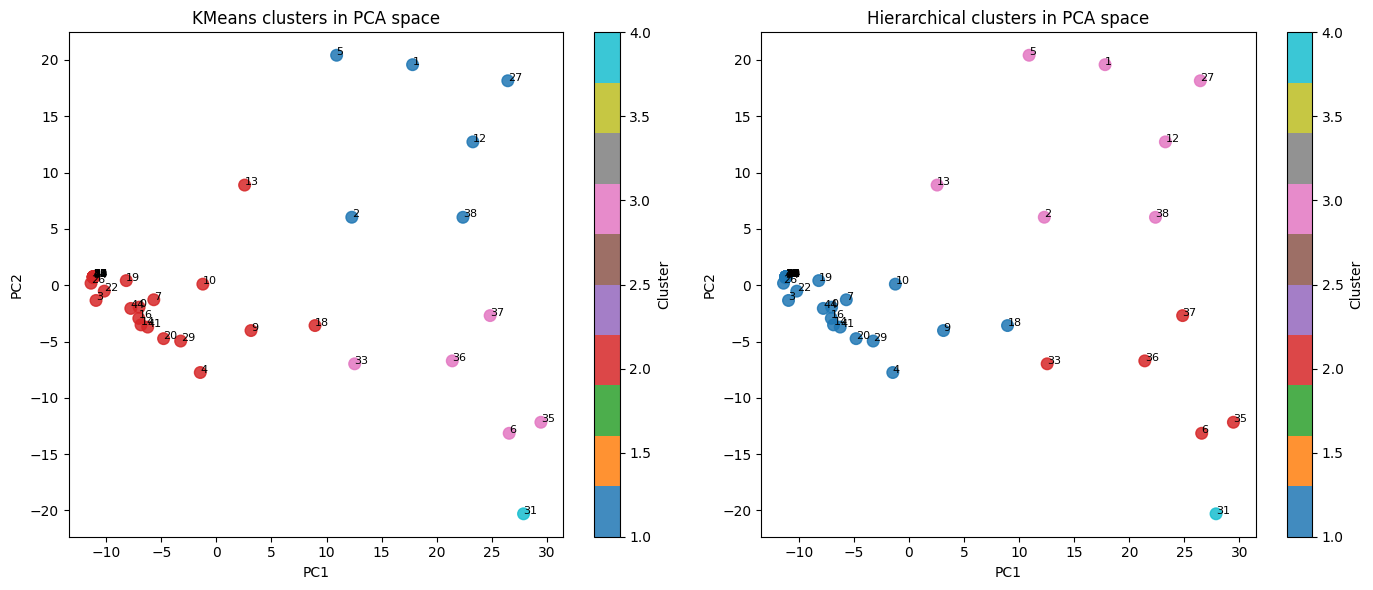

Saved: ../outputs/rgc_image_analysis/figures/rgc_clusters_pca_space_revised.tiff


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cluster_col, title in zip(
    axes,
    ["kmeans_cluster", "hierarchical_cluster"],
    ["KMeans clusters in PCA space", "Hierarchical clusters in PCA space"]
):
    sc = ax.scatter(
        df["PC1"],
        df["PC2"],
        c=df[cluster_col],
        cmap="tab10",
        s=70,
        alpha=0.85
    )

    for _, row in df.iterrows():
        ax.text(
            row["PC1"],
            row["PC2"],
            str(row["image_index"]),
            fontsize=8
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, label="Cluster")

plt.tight_layout()

out_path = fig_dir / "rgc_clusters_pca_space_revised.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", out_path)

## 2. Per-cluster silhouette quality

Silhouette analysis estimates whether each image is closer to its own cluster than to neighboring clusters.

This is more informative than one global silhouette number because it identifies weak or overlapping clusters.

In [8]:
silhouette_tables = []

for cluster_col in cluster_cols:

    labels = df[cluster_col].values

    sil_values = silhouette_samples(
        X_pca,
        labels
    )

    df[f"{cluster_col}_silhouette"] = sil_values

    sil_summary = (
        df
        .groupby(cluster_col)[f"{cluster_col}_silhouette"]
        .agg(["count", "mean", "std", "min", "median", "max"])
        .round(4)
        .reset_index()
    )

    sil_summary.insert(0, "method", cluster_col)
    silhouette_tables.append(sil_summary)

    print("\n", cluster_col)
    print(
    "Overall silhouette:",
    round(
        silhouette_score(
            X_pca,
            labels
        ),
        4
    )
)
    display(sil_summary)

silhouette_summary = pd.concat(silhouette_tables, ignore_index=True)

silhouette_summary.to_csv(
    output_dir / "rgc_cluster_silhouette_summary.csv",
    index=False
)


 kmeans_cluster
Overall silhouette: 0.5463


,method,kmeans_cluster,count,mean,std,min,median,max
0,kmeans_cluster,1,6,0.0534,0.1053,-0.1325,0.0704,0.1609
1,kmeans_cluster,2,33,0.7196,0.1517,0.2138,0.8140,0.8213
2,kmeans_cluster,3,5,0.1029,0.0959,-0.0523,0.1333,0.1899
3,kmeans_cluster,4,1,0.0000,NaN,0.0000,0.0000,0.0000



 hierarchical_cluster
Overall silhouette: 0.5278


,method,hierarchical_cluster,count,mean,std,min,median,max
0,hierarchical_cluster,1,32,0.7237,0.1384,0.2159,0.8108,0.8149
1,hierarchical_cluster,2,5,0.0951,0.0913,-0.0501,0.1285,0.1710
2,hierarchical_cluster,3,7,0.0167,0.1828,-0.3549,0.0725,0.1866
3,hierarchical_cluster,4,1,0.0000,NaN,0.0000,0.0000,0.0000


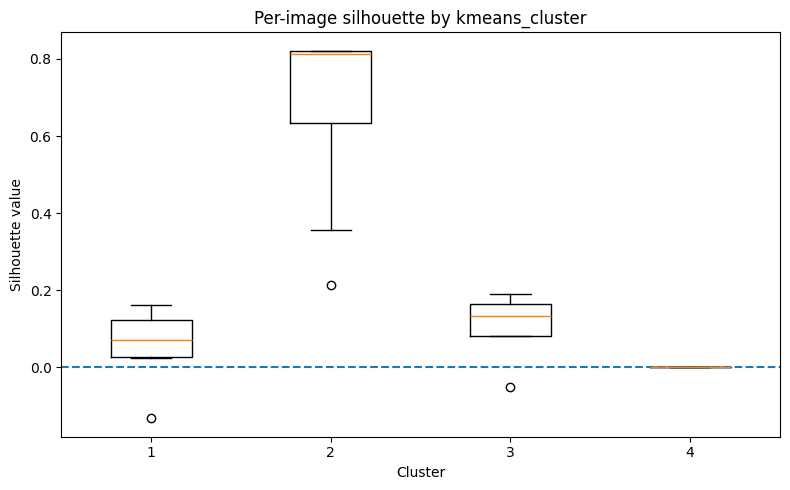

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_silhouette_boxplot.tiff


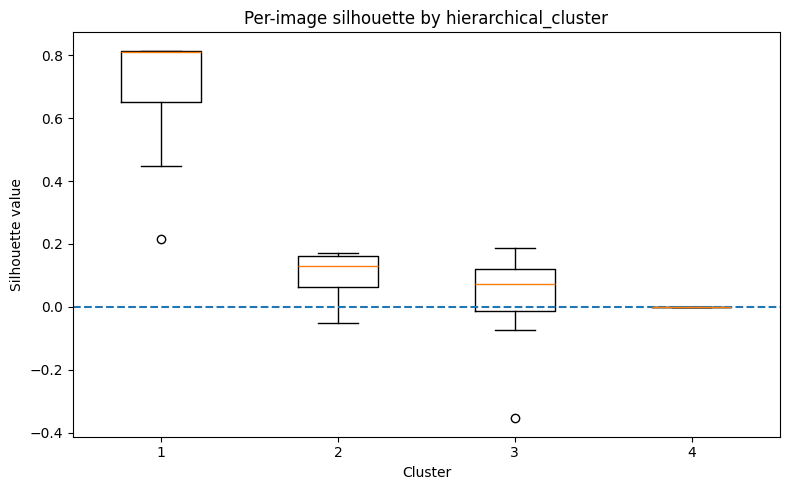

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_silhouette_boxplot.tiff


In [10]:
# Plot silhouette distributions by cluster.

for cluster_col in cluster_cols:

    plt.figure(figsize=(8, 5))

    clusters = sorted(df[cluster_col].unique())

    data = [
        df.loc[df[cluster_col] == cluster, f"{cluster_col}_silhouette"].values
        for cluster in clusters
    ]

    plt.boxplot(
    data,
    tick_labels=clusters
)

    plt.axhline(0, linestyle="--")
    plt.xlabel("Cluster")
    plt.ylabel("Silhouette value")
    plt.title(f"Per-image silhouette by {cluster_col}")
    plt.tight_layout()

    out_path = fig_dir / f"rgc_{cluster_col}_silhouette_boxplot.tiff"
    plt.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out_path)

## 3. Representative / prototype images

For each cluster, find the image closest to the cluster centroid in PCA space.

These are useful as visual prototypes for manual biological interpretation.

In [11]:
def find_cluster_prototypes(df, cluster_col, X_space, n_prototypes=3):

    rows = []

    labels = df[cluster_col].values

    for cluster in sorted(np.unique(labels)):

        idxs = np.where(labels == cluster)[0]

        cluster_points = X_space[idxs]

        centroid = cluster_points.mean(axis=0)

        distances = np.linalg.norm(
            cluster_points - centroid,
            axis=1
        )

        order = np.argsort(distances)

        for rank in range(min(n_prototypes, len(order))):

            local_idx = order[rank]
            global_idx = idxs[local_idx]

            rows.append({
                "method": cluster_col,
                "cluster": cluster,
                "prototype_rank": rank + 1,
                "image_index": df.iloc[global_idx]["image_index"],
                "filename": df.iloc[global_idx]["filename"],
                "distance_to_cluster_centroid": distances[local_idx]
            })

    return pd.DataFrame(rows)


prototype_tables = []

for cluster_col in cluster_cols:
    prototypes = find_cluster_prototypes(
        df=df,
        cluster_col=cluster_col,
        X_space=X_pca,
        n_prototypes=3
    )
    prototype_tables.append(prototypes)

prototypes_df = pd.concat(prototype_tables, ignore_index=True)

prototype_path = output_dir / "rgc_cluster_prototype_images.csv"
prototypes_df.to_csv(prototype_path, index=False)

display(prototypes_df)

print("Saved:", prototype_path)

,method,cluster,prototype_rank,image_index,filename,distance_to_cluster_centroid
0,kmeans_cluster,1,1,2,cropped10.tif,16.606410
1,kmeans_cluster,1,2,1,cropped1.tif,20.485122
2,kmeans_cluster,1,3,5,cropped13.tif,22.890973
3,kmeans_cluster,2,1,22,cropped29.tif,3.564251
4,kmeans_cluster,2,2,19,cropped26.tif,3.863953
5,kmeans_cluster,2,3,0,cropped0.tif,4.062106
6,kmeans_cluster,3,1,36,cropped41.tif,11.963066
7,kmeans_cluster,3,2,33,cropped39.tif,20.619109
8,kmeans_cluster,3,3,37,cropped42.tif,22.235323
9,kmeans_cluster,4,1,31,cropped37.tif,0.000000


Saved: ../outputs/rgc_image_analysis/rgc_cluster_prototype_images.csv


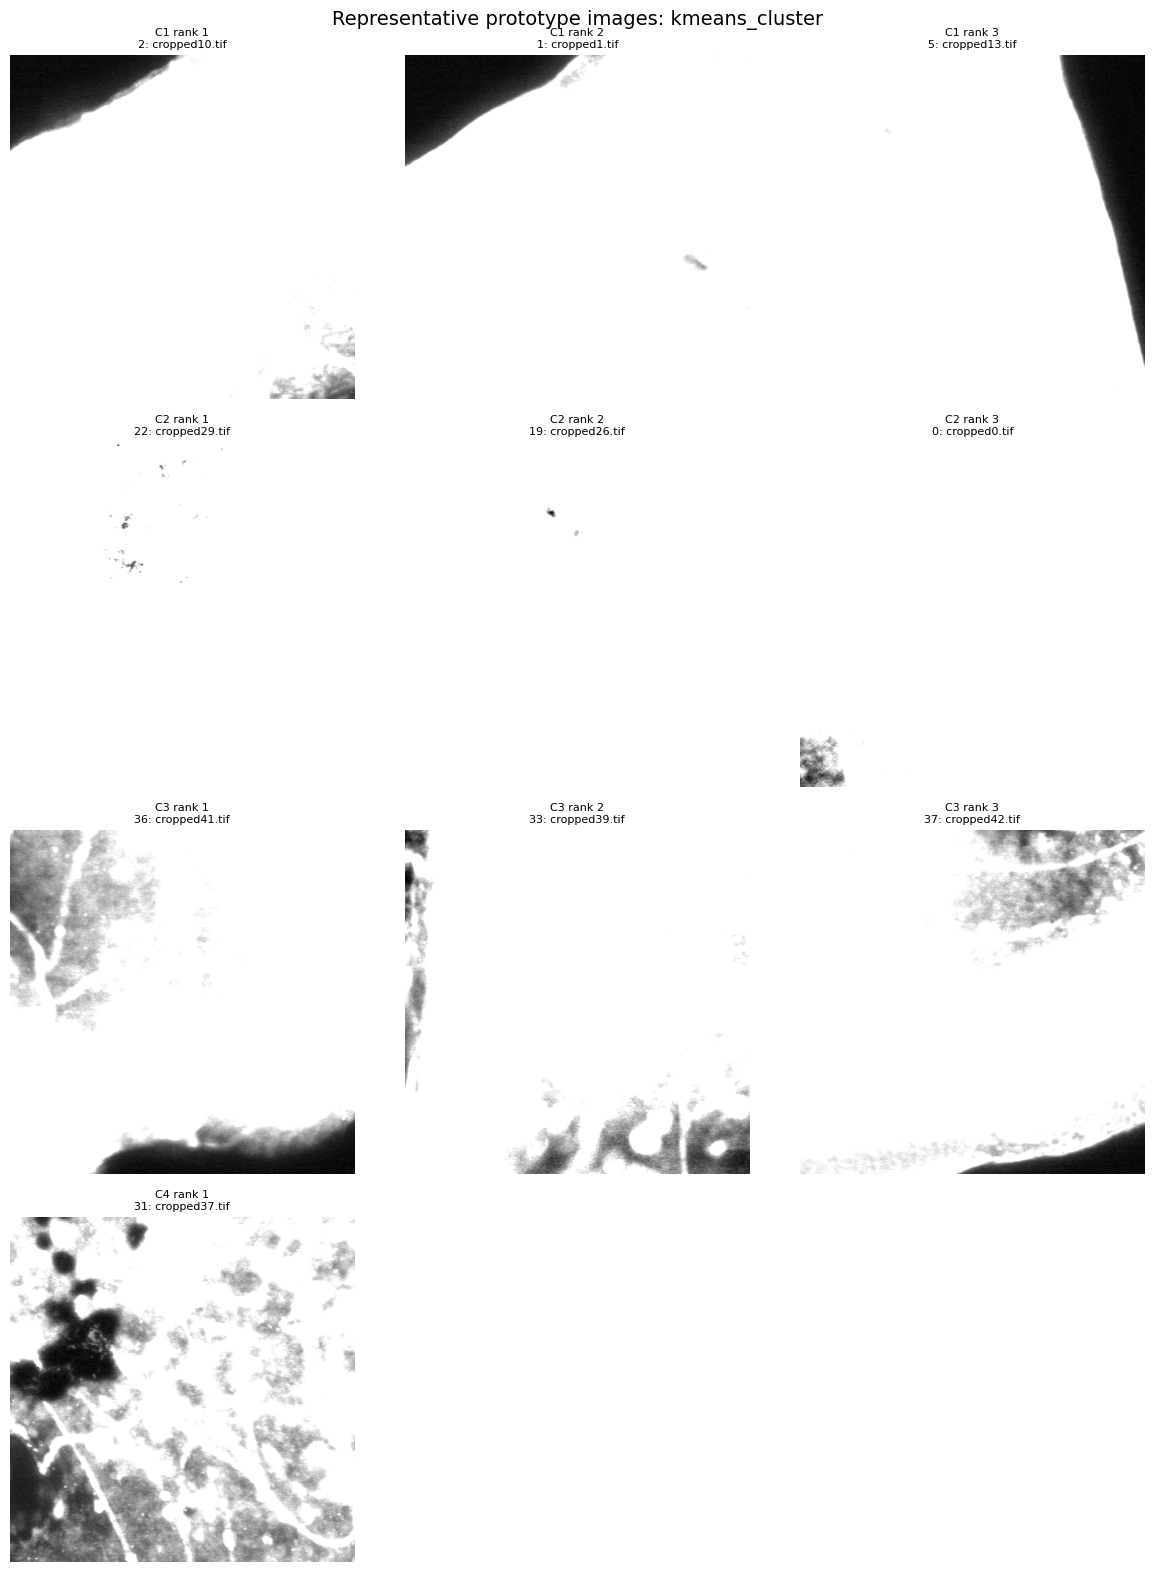

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_kmeans_cluster_prototype_contact_sheet.tiff


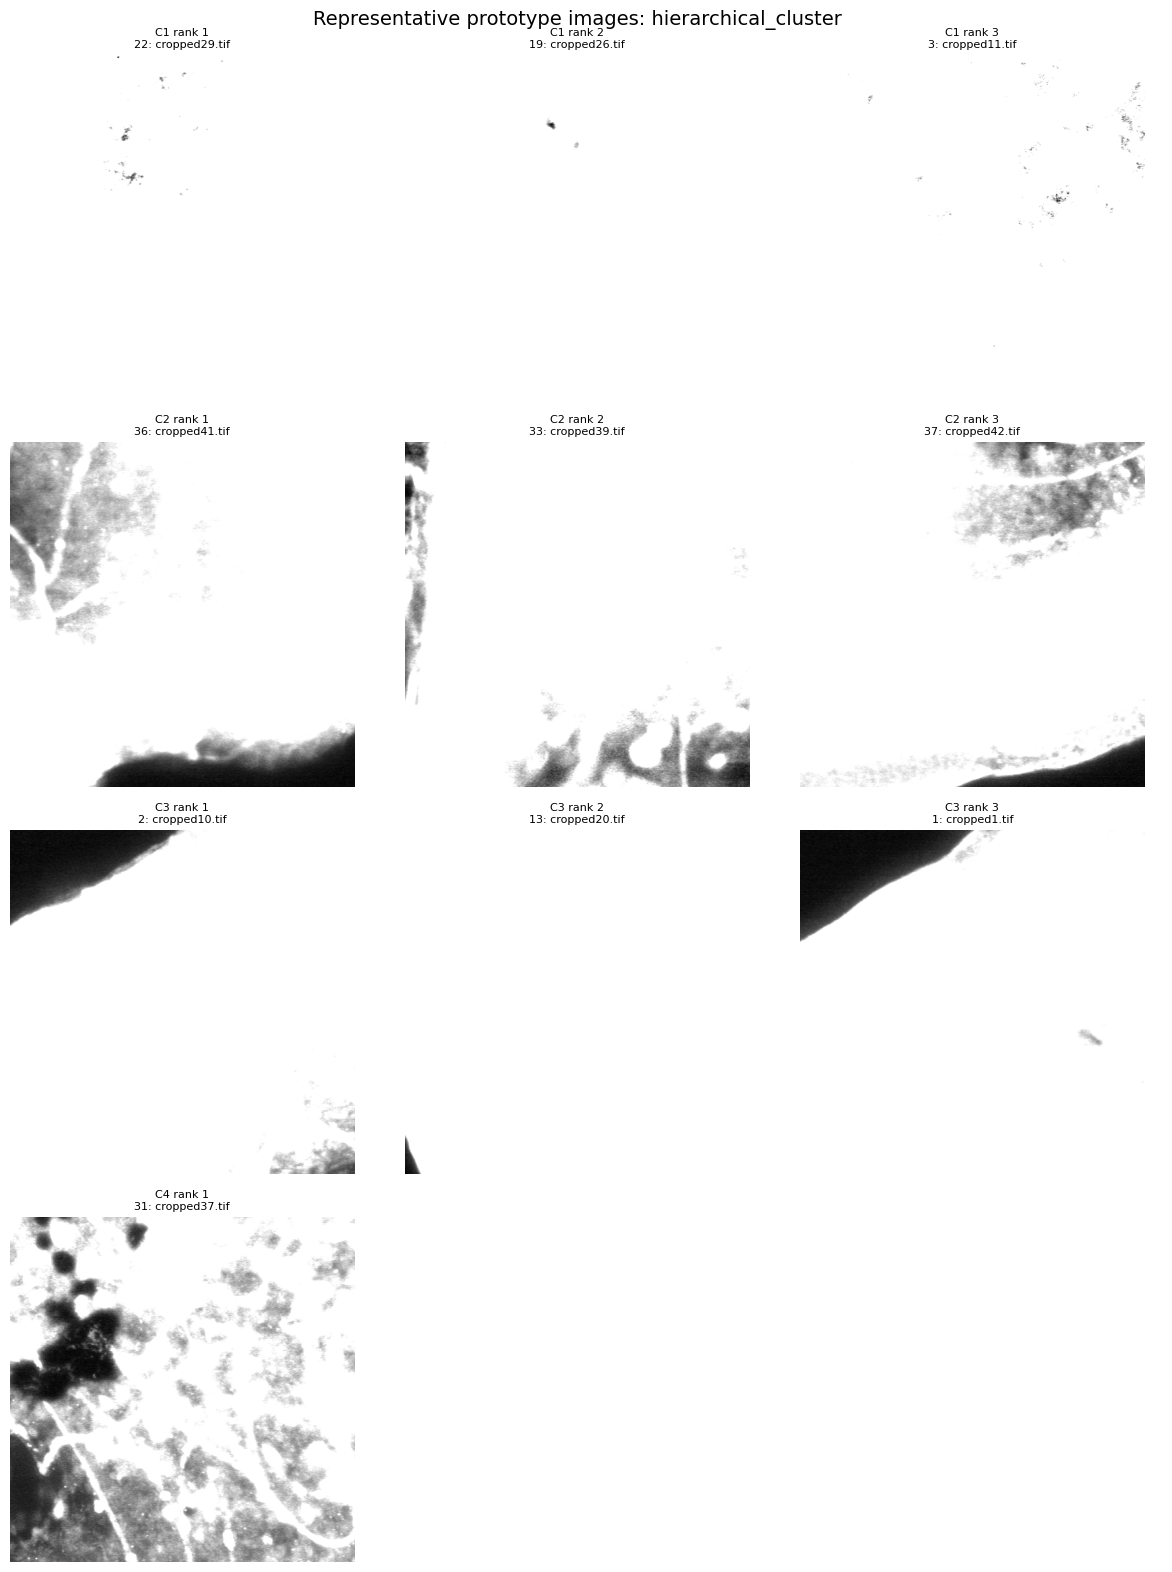

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_hierarchical_cluster_prototype_contact_sheet.tiff


In [12]:
def plot_prototype_contact_sheet(prototypes_df, method_name):

    sub = prototypes_df[
        prototypes_df["method"] == method_name
    ].copy()

    n = len(sub)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 4 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sub.iterrows()):

        img = Image.open(
            data_dir / row["filename"]
        ).convert("L")

        ax.imshow(img, cmap="gray")
        ax.set_title(
            f'C{row["cluster"]} rank {row["prototype_rank"]}\n{row["image_index"]}: {row["filename"]}',
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(
        f"Representative prototype images: {method_name}",
        fontsize=14
    )
    plt.tight_layout()

    out_path = review_dir / f"rgc_{method_name}_prototype_contact_sheet.tiff"
    fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", out_path)


for method_name in cluster_cols:
    plot_prototype_contact_sheet(
        prototypes_df,
        method_name
    )

## 4. Cluster contact sheets

This creates image grids for each cluster. These are for manual morphology review, not statistical testing.

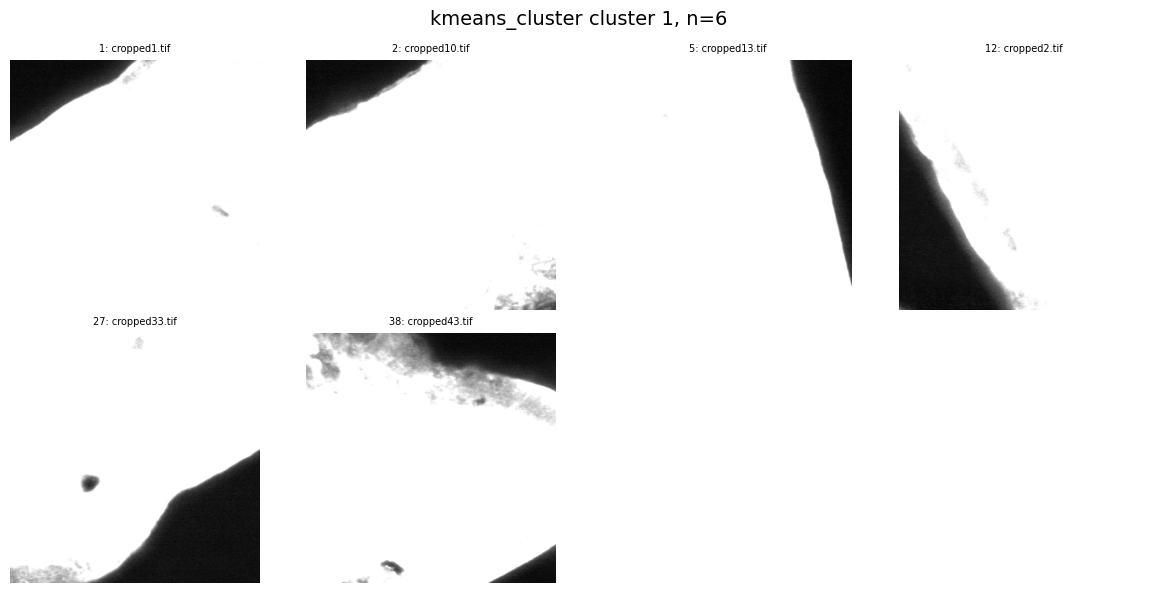

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_kmeans_cluster_cluster_1_contact_sheet.tiff


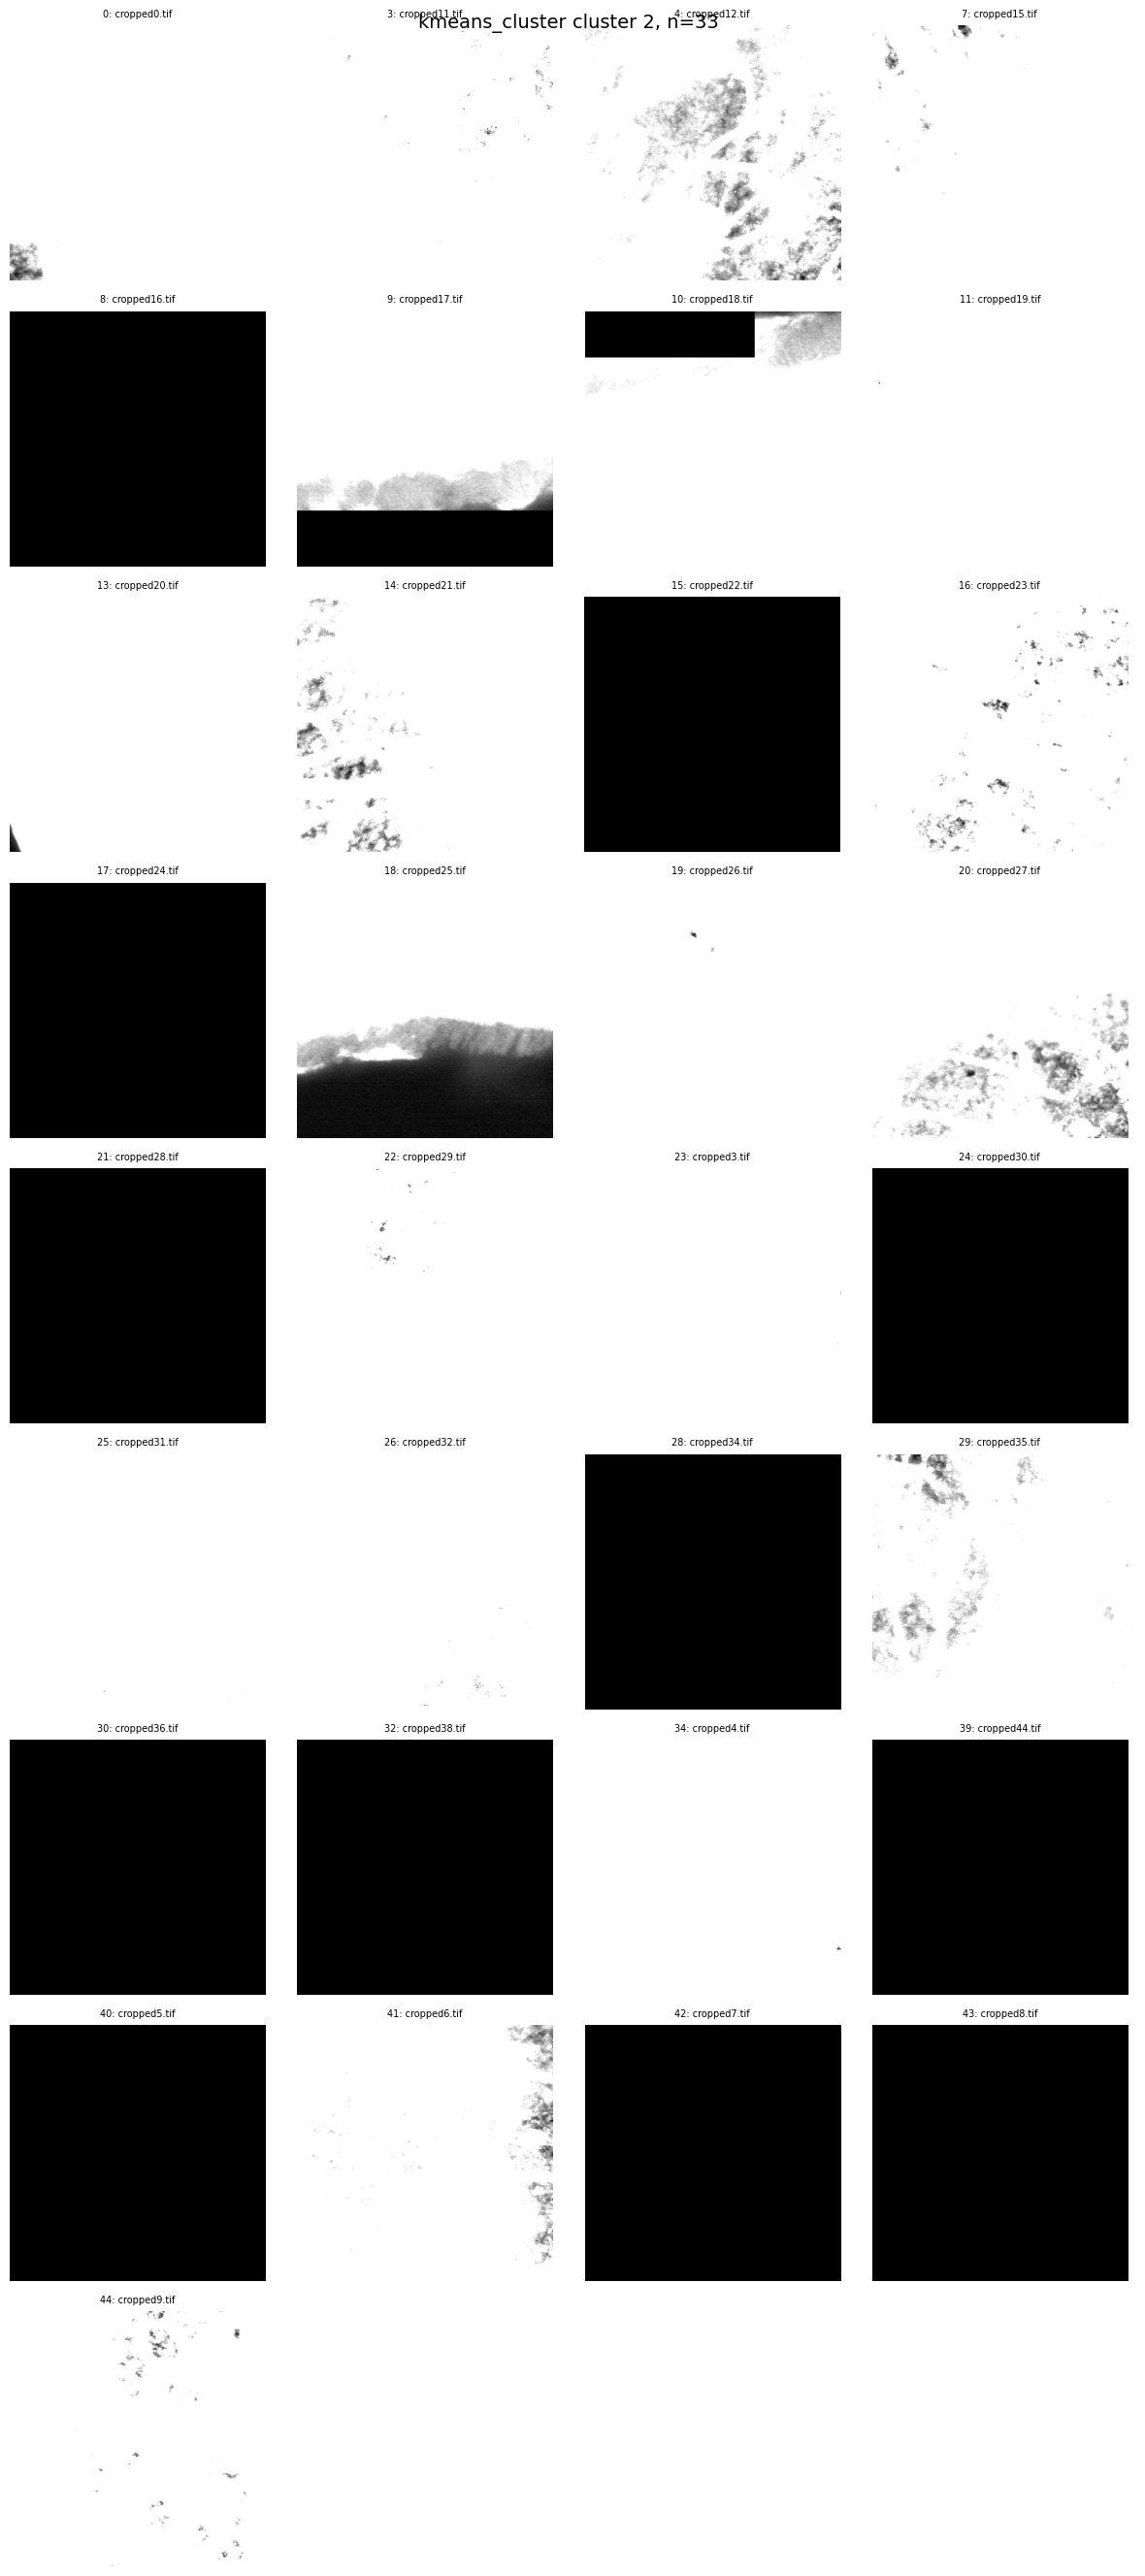

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_kmeans_cluster_cluster_2_contact_sheet.tiff


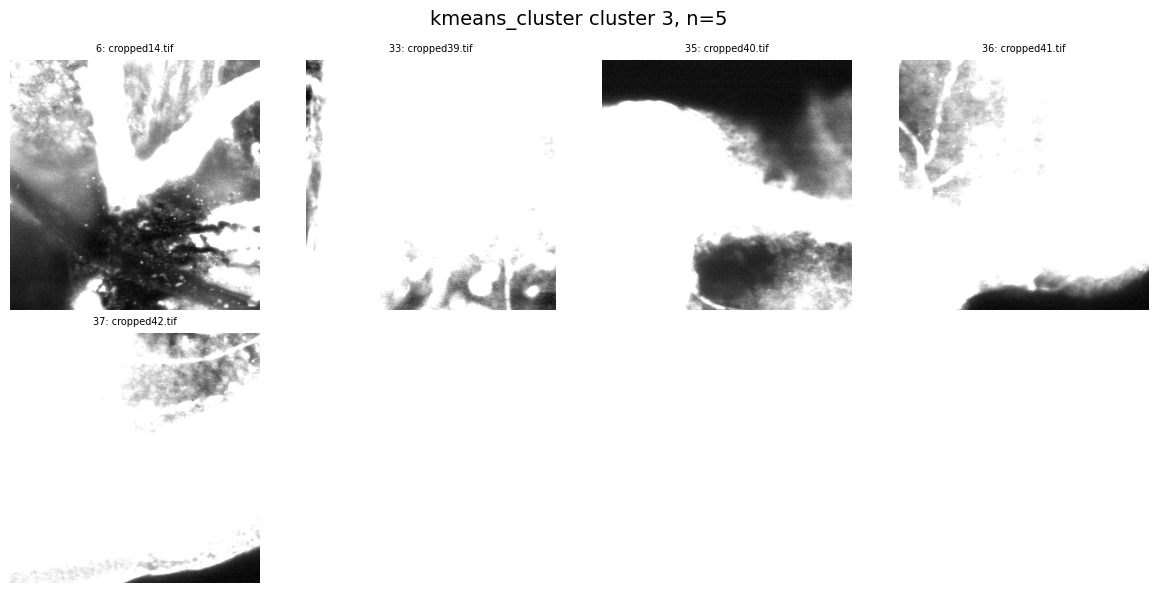

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_kmeans_cluster_cluster_3_contact_sheet.tiff


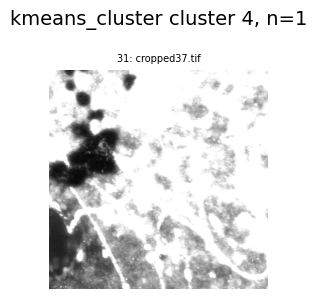

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_kmeans_cluster_cluster_4_contact_sheet.tiff


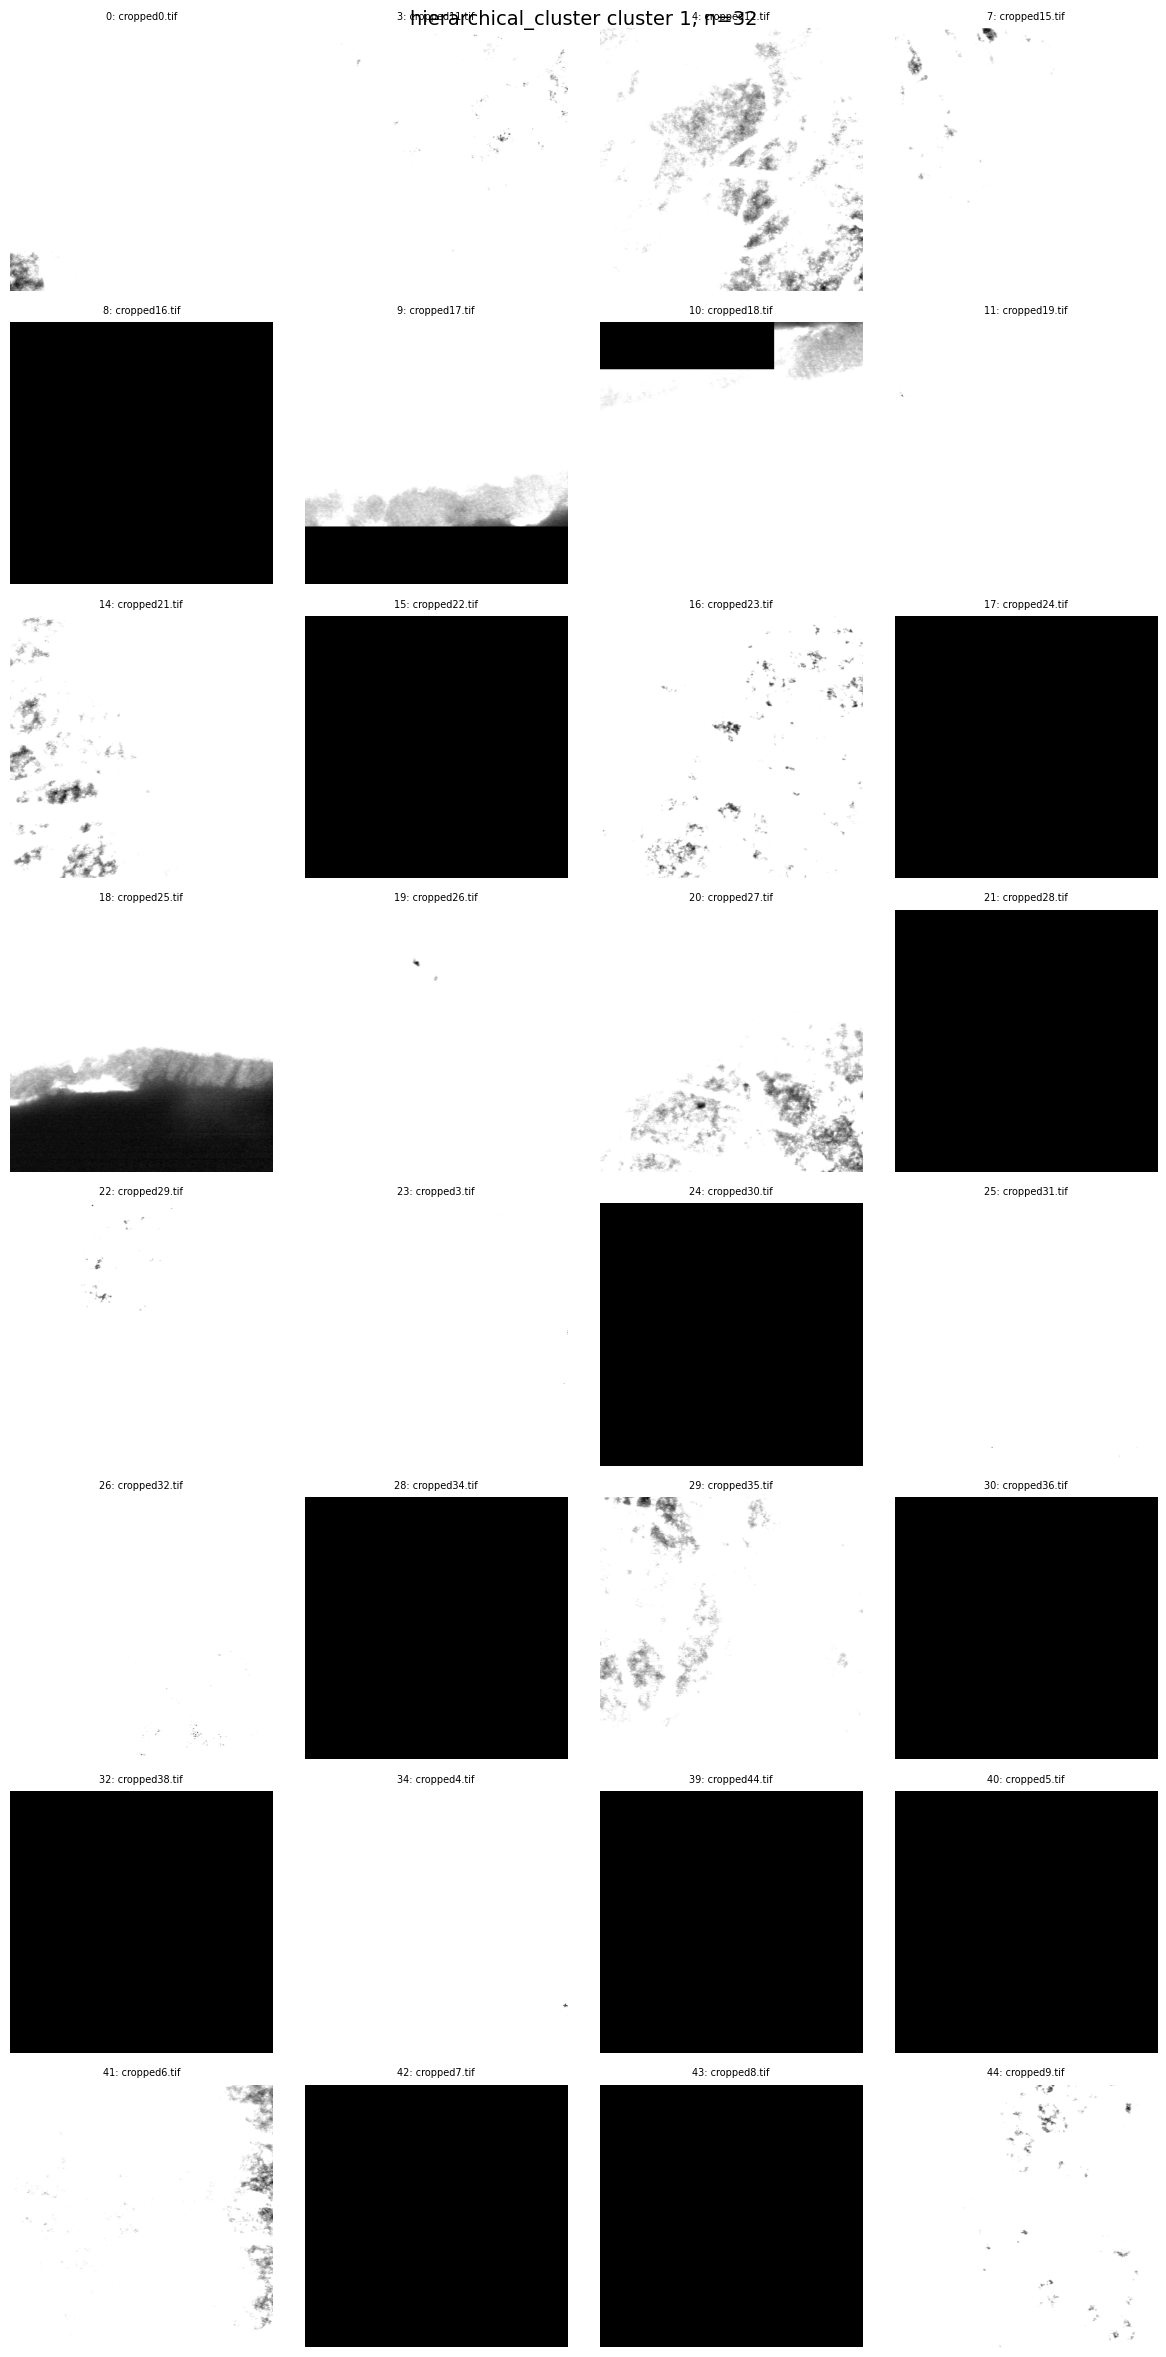

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_hierarchical_cluster_cluster_1_contact_sheet.tiff


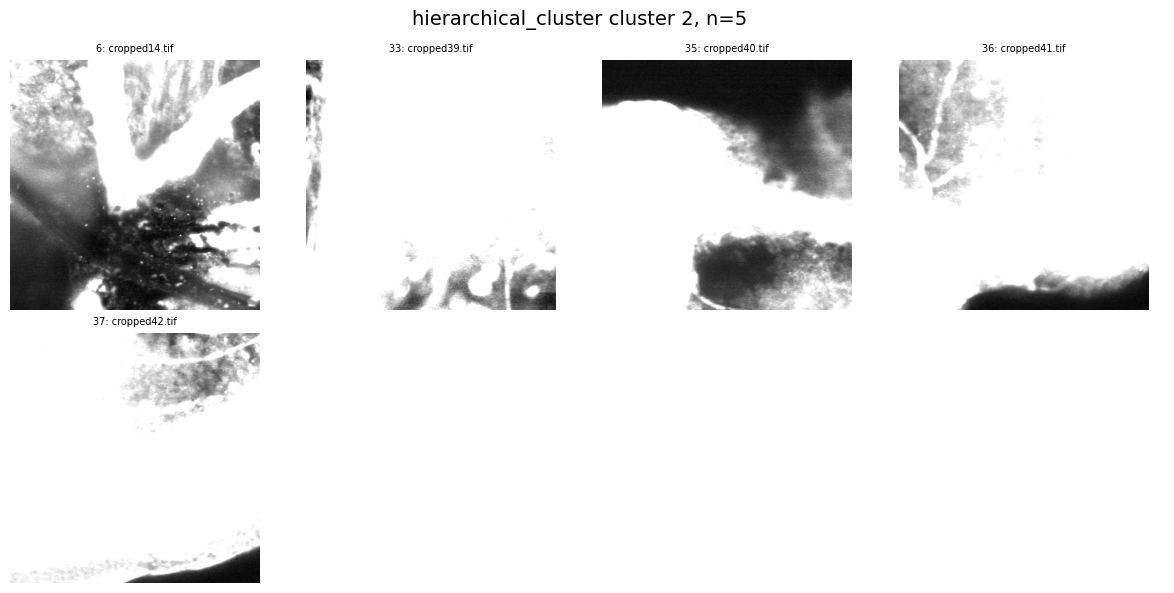

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_hierarchical_cluster_cluster_2_contact_sheet.tiff


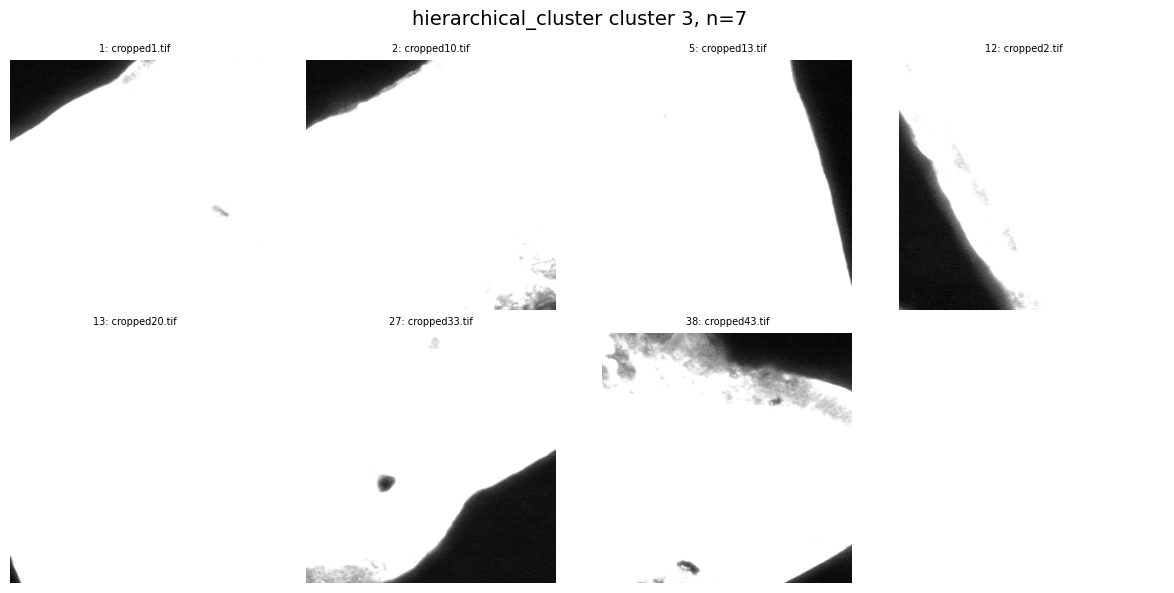

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_hierarchical_cluster_cluster_3_contact_sheet.tiff


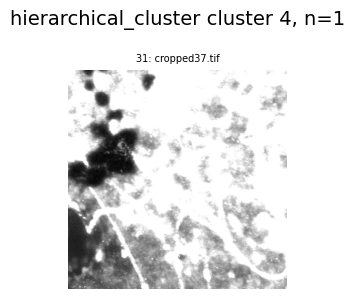

Saved: ../outputs/rgc_image_analysis/cluster_review/rgc_hierarchical_cluster_cluster_4_contact_sheet.tiff


In [13]:
def save_cluster_contact_sheets(method_col):

    for cluster in sorted(df[method_col].unique()):

        sub = df[
            df[method_col] == cluster
        ].copy()

        n = len(sub)

        n_cols = min(4, n)
        n_rows = int(np.ceil(n / n_cols))

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(3 * n_cols, 3 * n_rows)
        )

        axes = np.array(axes).reshape(-1)

        for ax, (_, row) in zip(axes, sub.iterrows()):

            img = Image.open(
                data_dir / row["filename"]
            ).convert("L")

            ax.imshow(img, cmap="gray")
            ax.set_title(
                f'{row["image_index"]}: {row["filename"]}',
                fontsize=7
            )
            ax.axis("off")

        for ax in axes[n:]:
            ax.axis("off")

        plt.suptitle(
            f"{method_col} cluster {cluster}, n={n}",
            fontsize=14
        )
        plt.tight_layout()

        out_path = review_dir / f"rgc_{method_col}_cluster_{cluster}_contact_sheet.tiff"
        fig.savefig(
            out_path,
            dpi=300,
            format="tiff",
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

        print("Saved:", out_path)


for cluster_col in cluster_cols:
    save_cluster_contact_sheets(cluster_col)

## 5. Interpretable image morphology features

This section extracts simple image-level morphology proxies from each image:

- mean intensity
- foreground fraction
- foreground area
- bounding box aspect ratio
- eccentricity
- solidity
- perimeter
- skeleton length

These are not perfect neuronal reconstructions, but they help interpret whether clusters are driven by obvious image morphology/quality differences.

In [15]:
def extract_image_features(path):

    img = Image.open(path).convert("L")
    arr = np.array(img).astype(float)

    arr_norm = (
        arr - arr.min()
    ) / (
        arr.max() - arr.min() + 1e-8
    )

    features = {
        "mean_intensity": arr_norm.mean(),
        "std_intensity": arr_norm.std(),
        "min_intensity": arr_norm.min(),
        "max_intensity": arr_norm.max()
    }

    if not SKIMAGE_AVAILABLE:
        return features

    try:
        threshold = threshold_otsu(arr_norm)
    except ValueError:
        threshold = arr_norm.mean()

    # Assumes fluorescent/bright cell on darker background.
    mask = arr_norm > threshold

    # Remove tiny specks.
    mask = remove_small_objects(
        mask,
        max_size=19
    )

    features["foreground_fraction"] = mask.mean()
    features["foreground_area_pixels"] = int(mask.sum())

    labeled = label(mask)

    props = regionprops(labeled)

    if len(props) == 0:
        features.update({
            "largest_object_area": 0,
            "bbox_area": 0,
            "bbox_aspect_ratio": np.nan,
            "eccentricity": np.nan,
            "solidity": np.nan,
            "perimeter": np.nan,
            "skeleton_length": 0
        })
        return features

    # Use largest connected component as a rough cell body/arbor object.
    largest = max(
        props,
        key=lambda p: p.area
    )

    minr, minc, maxr, maxc = largest.bbox
    bbox_height = maxr - minr
    bbox_width = maxc - minc

    bbox_area = bbox_height * bbox_width

    skeleton = skeletonize(mask)

    features.update({
        "largest_object_area": largest.area,
        "bbox_area": bbox_area,
        "bbox_aspect_ratio": bbox_width / (bbox_height + 1e-8),
        "eccentricity": largest.eccentricity,
        "solidity": largest.solidity,
        "perimeter": largest.perimeter,
        "skeleton_length": int(skeleton.sum())
    })

    return features


morph_rows = []

for _, row in df.iterrows():

    path = data_dir / row["filename"]

    feats = extract_image_features(path)
    feats["image_index"] = row["image_index"]
    feats["filename"] = row["filename"]

    morph_rows.append(feats)

morph_df = pd.DataFrame(morph_rows)

df_morph = df.merge(
    morph_df,
    on=["image_index", "filename"],
    how="left"
)

morph_path = output_dir / "rgc_image_morphology_features.csv"
df_morph.to_csv(morph_path, index=False)

print("Saved:", morph_path)
display(df_morph.head())

Saved: ../outputs/rgc_image_analysis/rgc_image_morphology_features.csv


,image_index,filename,kmeans_cluster,hierarchical_cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,PC1,PC2,kmeans_cluster_silhouette,hierarchical_cluster_silhouette,mean_intensity,std_intensity,min_intensity,max_intensity,foreground_fraction,foreground_area_pixels,largest_object_area,bbox_area,bbox_aspect_ratio,eccentricity,solidity,perimeter,skeleton_length
0,0,cropped0.tif,2,1,0.073215,0.105922,0.000000,0.100159,0.162834,0.005846,0.132512,0.104217,0.457121,0.040562,0.066822,0.195931,0.010781,0.608554,0.035006,0.149179,0.000000,0.028462,0.436826,0.324956,0.097127,0.067308,0.011614,0.198564,0.143741,0.061214,0.001731,0.140818,0.000000,0.189425,0.233931,0.022299,0.189681,0.003772,0.026788,0.276662,0.004156,0.074964,0.029493,0.000000,0.006400,0.000000,0.034805,0.268721,0.036252,0.023519,0.233775,0.013192,0.000000,0.339112,0.502807,0.124392,0.013595,0.480306,2.921835,0.082452,0.386178,0.047851,0.041763,0.691310,0.076632,0.037175,0.214812,0.000000,0.551156,0.010876,0.251945,0.033046,0.365441,0.166702,0.005288,0.225185,0.226746,0.000000,0.164457,0.148557,0.021172,0.000000,0.198238,0.094568,0.140919,3.339190,0.030332,0.218602,0.084109,0.098518,0.129591,0.240491,0.454476,0.003885,0.155195,0.223735,0.075388,0.000000,0.062014,0.161563,0.186032,0.273811,0.004712,0.000000,0.000991,0.072014,0.044057,0.085861,1.458739,4.906004,0.299210,0.088368,0.224986,0.089188,0.063572,0.128436,0.133560,0.024070,0.000000,0.036091,0.135930,0.094469,0.533833,0.193793,0.189795,0.028332,0.137035,0.114833,0.225232,0.146268,0.000000,0.000000,0.067938,0.016193,0.013071,0.281509,0.026704,0.146024,0.110655,0.075924,0.006756,0.000042,0.000000,0.017896,0.003982,0.346411,0.458806,0.000000,0.035969,0.262957,0.319661,0.799324,0.155418,0.809928,0.000000,0.197243,0.040950,0.109998,0.462014,0.014588,0.259736,0.003072,0.000000,0.003165,0.009036,0.012267,0.169838,0.284679,0.006069,0.040901,0.468056,0.013062,0.321720,0.232141,0.039135,0.181297,0.105019,0.035101,0.083223,0.698969,0.001348,0.000000,0.023670,0.011009,0.000658,0.442000,0.430005,0.052693,0.026958,0.033702,0.079906,0.205457,0.000000,0.177917,0.055078,0.

In [16]:
morph_feature_cols = [
    col for col in morph_df.columns
    if col not in ["image_index", "filename"]
]

display(
    df_morph[morph_feature_cols]
    .describe()
    .round(4)
)

,mean_intensity,std_intensity,min_intensity,max_intensity,foreground_fraction,foreground_area_pixels,largest_object_area,bbox_area,bbox_aspect_ratio,eccentricity,solidity,perimeter,skeleton_length
count,45.0000,45.0000,45.0,45.0000,45.0000,45.0000,45.0000,45.0000,33.0000,33.0000,33.0000,33.0000,45.0000
mean,0.6730,0.1150,0.0,0.7333,0.6617,173461.7111,172393.7333,186356.6222,1.0429,0.3319,0.9586,4082.0593,3915.4000
std,0.4209,0.1395,0.0,0.4472,0.4166,109200.0985,109476.6470,115336.6844,0.1293,0.2586,0.0597,3061.9718,4993.3891
min,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0045,0.7489,1886.0366,0.0000
25%,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0934,0.9411,2067.9350,0.0000
50%,0.9046,0.0395,0.0,1.0000,0.8804,230792.0000,230612.0000,262144.0000,1.0000,0.2759,0.9896,2876.7321,1555.0000
75%,0.9943,0.2367,0.0,1.0000,0.9894,259365.0000,259171.0000,262144.0000,1.0000,0.5402,0.9968,4625.9173,6129.0000
max,1.0000,0.4096,0.0,1.0000,1.0000,262141.0000,262141.0000,262144.0000,1.6101,0.8200,1.0000,15566.6628,21569.0000


## 6. Morphology feature profiles by cluster

This does not test whether cluster labels agree; it asks whether discovered clusters differ in interpretable visual properties.

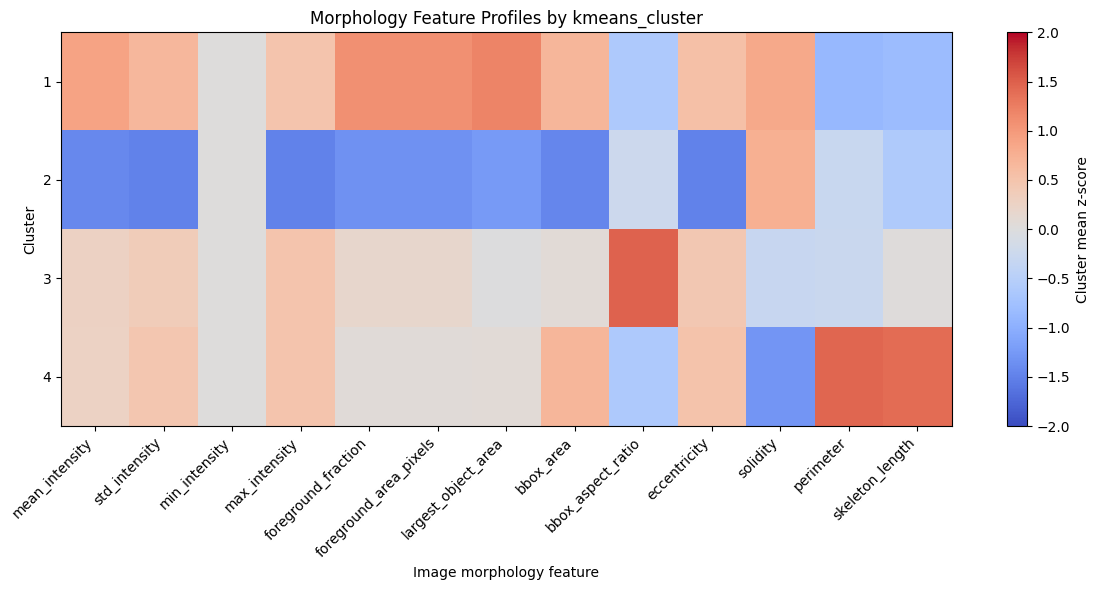

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_morphology_profile_heatmap.tiff


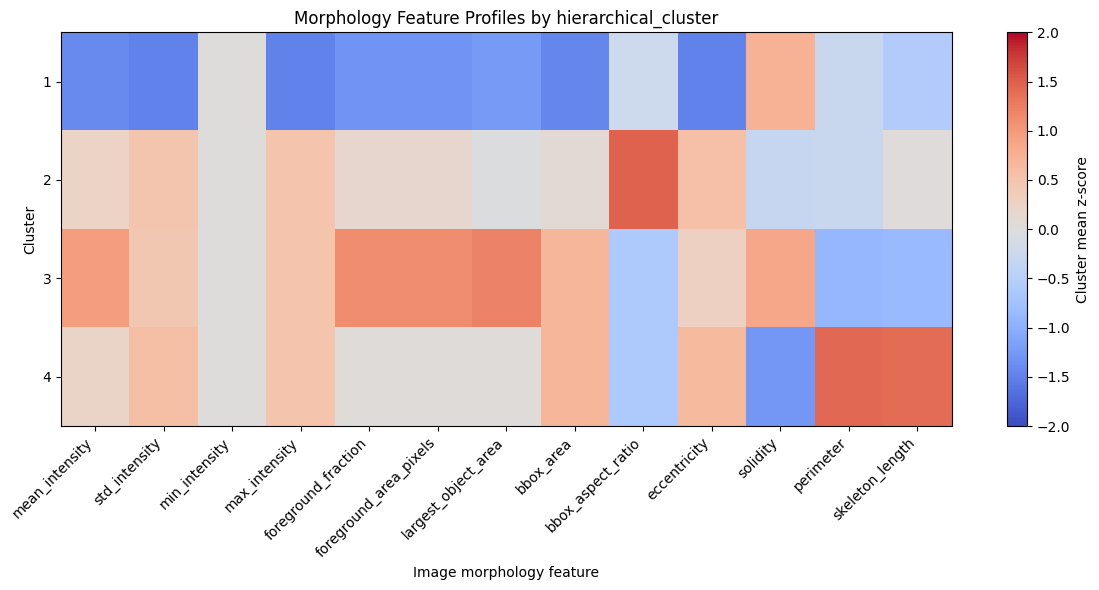

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_morphology_profile_heatmap.tiff


In [17]:
for cluster_col in cluster_cols:

    cluster_means = (
        df_morph
        .groupby(cluster_col)[morph_feature_cols]
        .mean()
    )

    # z-score each feature across clusters for visualization.
    z = (
        cluster_means - cluster_means.mean(axis=0)
    ) / (
        cluster_means.std(axis=0) + 1e-8
    )

    fig = plt.figure(figsize=(12, 6))
    plt.imshow(
        z.values,
        aspect="auto",
        cmap="coolwarm",
        vmin=-2,
        vmax=2
    )

    plt.xticks(
        ticks=np.arange(len(z.columns)),
        labels=z.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks=np.arange(len(z.index)),
        labels=z.index
    )

    plt.colorbar(label="Cluster mean z-score")
    plt.xlabel("Image morphology feature")
    plt.ylabel("Cluster")
    plt.title(f"Morphology Feature Profiles by {cluster_col}")
    plt.tight_layout()

    out_path = fig_dir / f"rgc_{cluster_col}_morphology_profile_heatmap.tiff"
    fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    cluster_means.to_csv(
        output_dir / f"rgc_{cluster_col}_morphology_feature_means.csv"
    )

    print("Saved:", out_path)

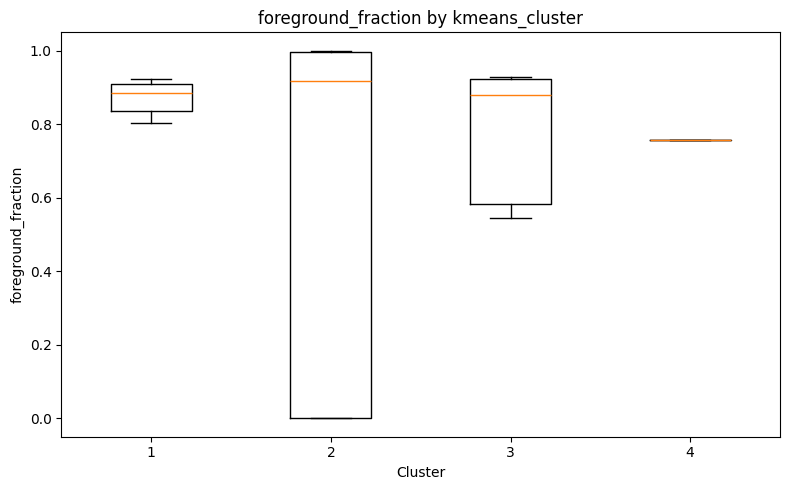

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_foreground_fraction_boxplot.tiff


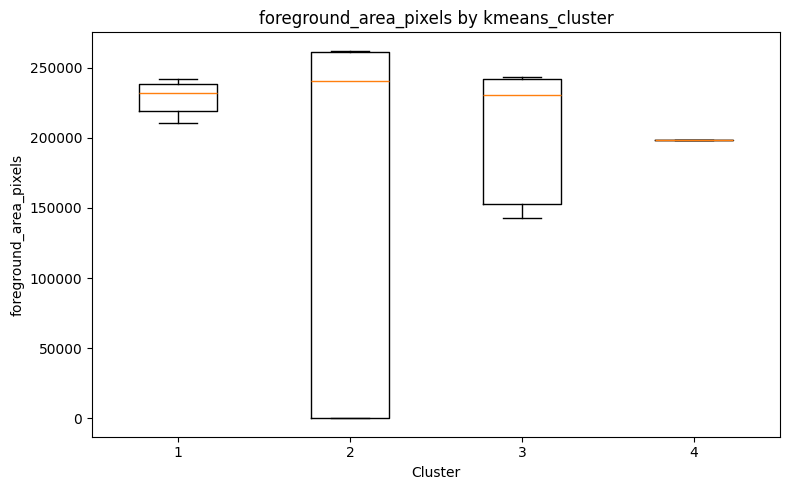

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_foreground_area_pixels_boxplot.tiff


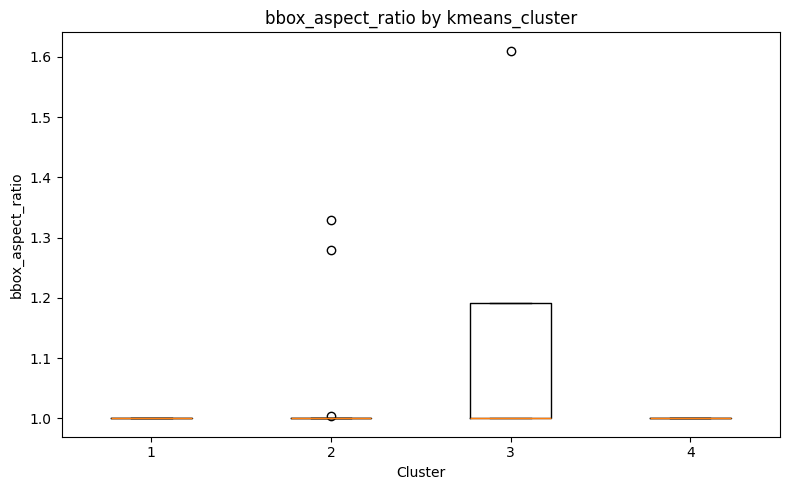

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_bbox_aspect_ratio_boxplot.tiff


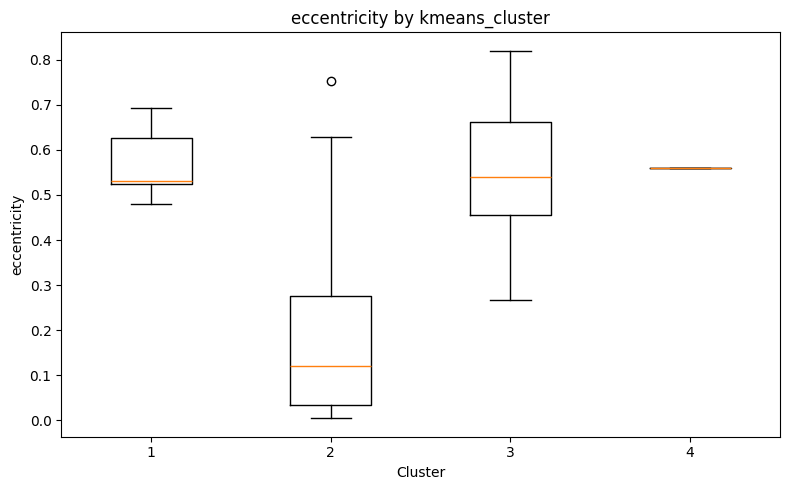

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_eccentricity_boxplot.tiff


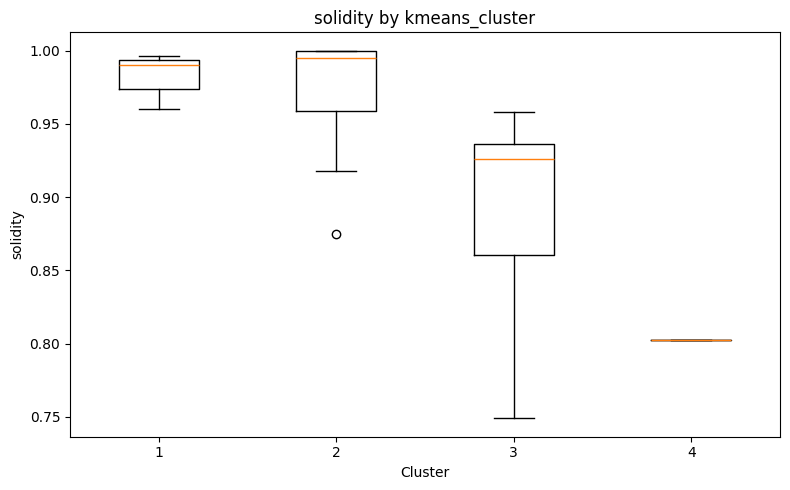

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_solidity_boxplot.tiff


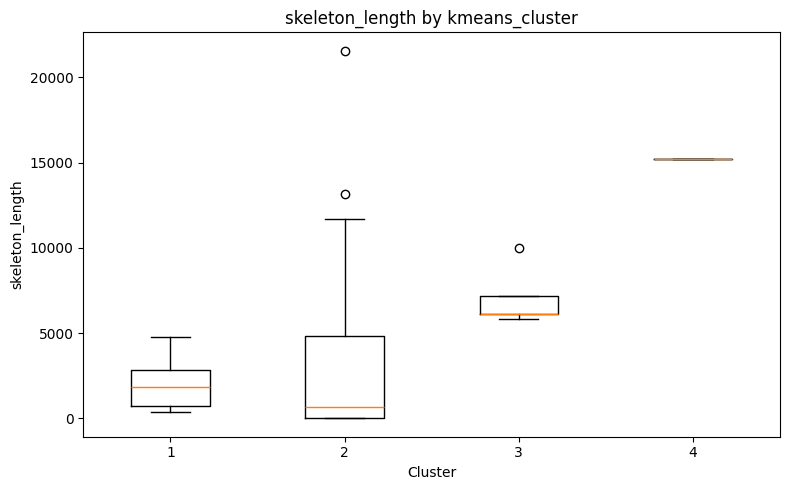

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_skeleton_length_boxplot.tiff


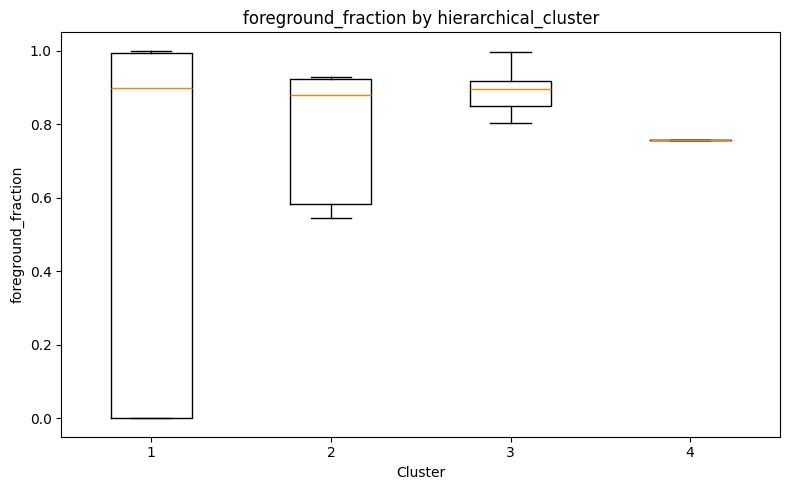

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_foreground_fraction_boxplot.tiff


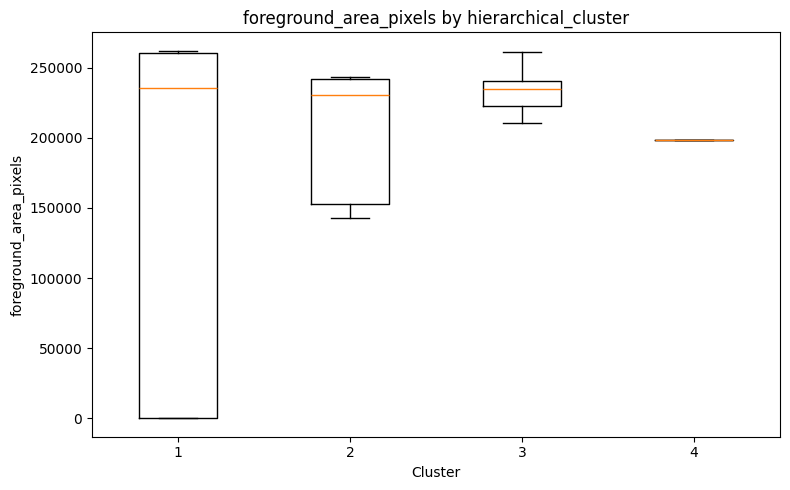

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_foreground_area_pixels_boxplot.tiff


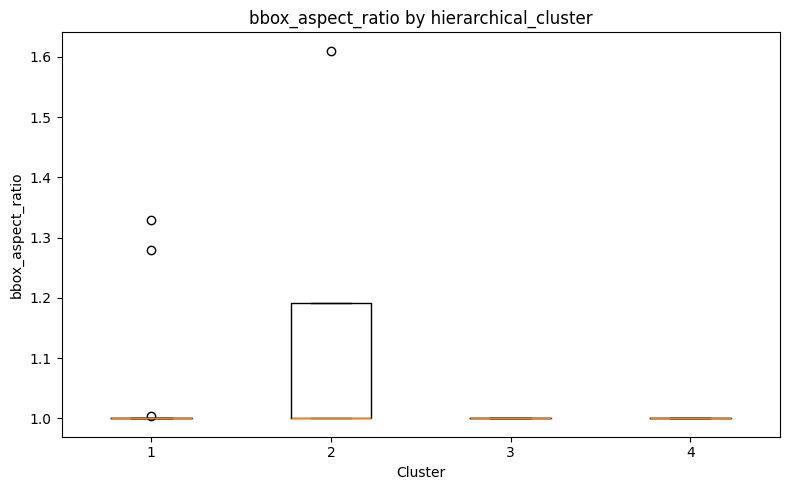

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_bbox_aspect_ratio_boxplot.tiff


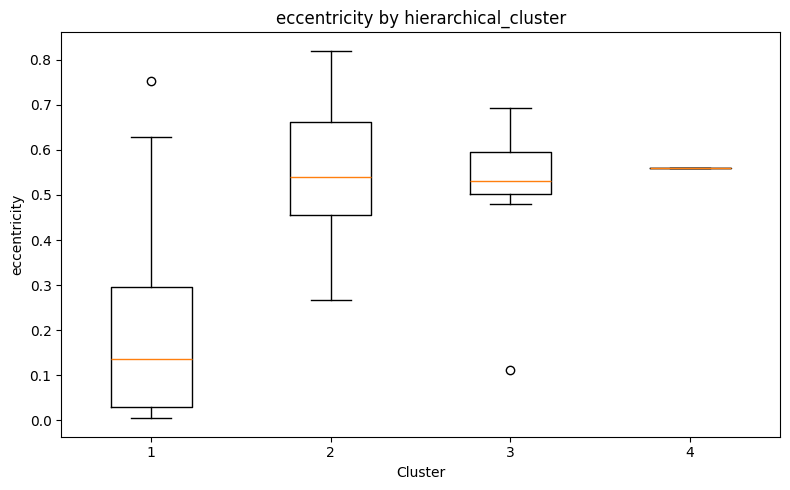

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_eccentricity_boxplot.tiff


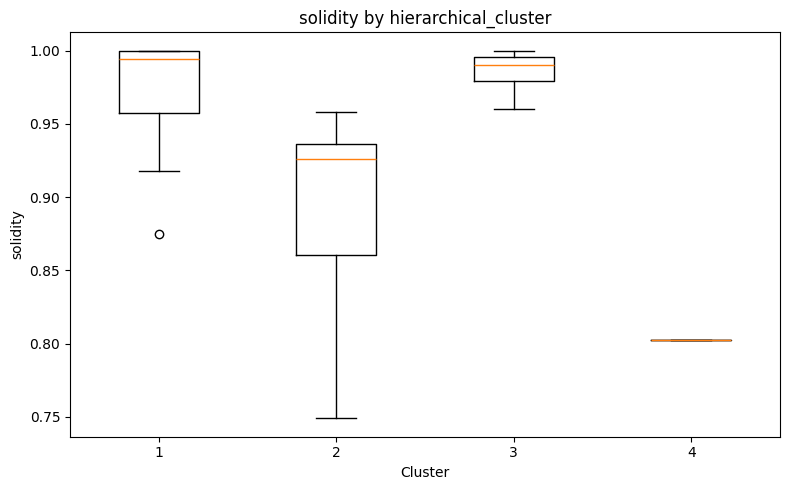

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_solidity_boxplot.tiff


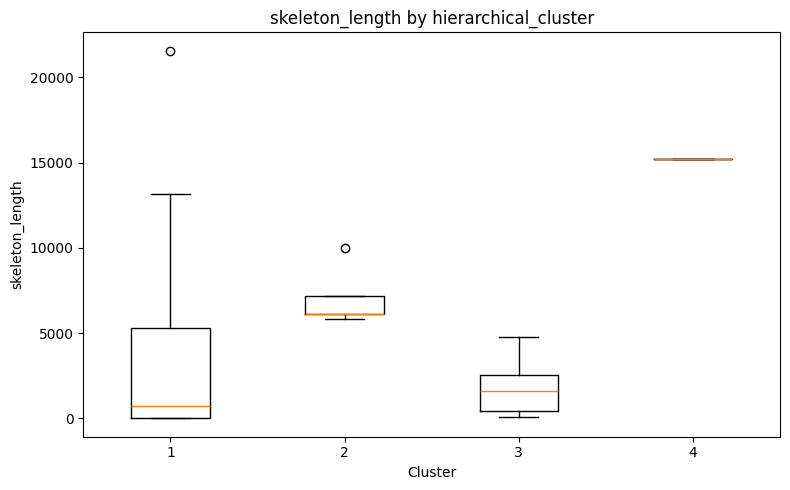

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_skeleton_length_boxplot.tiff


In [23]:
# Boxplots for selected morphology features.

selected_morph_features = [
    "foreground_fraction",
    "foreground_area_pixels",
    "bbox_aspect_ratio",
    "eccentricity",
    "solidity",
    "skeleton_length"
]

selected_morph_features = [
    f for f in selected_morph_features
    if f in df_morph.columns
]

for cluster_col in cluster_cols:

    for feature in selected_morph_features:

        fig = plt.figure(figsize=(8, 5))

        clusters = sorted(df_morph[cluster_col].unique())

        data = [
            df_morph.loc[df_morph[cluster_col] == cluster, feature].dropna().values
            for cluster in clusters
        ]

        plt.boxplot(
            data,
            tick_labels=clusters
        )

        plt.xlabel("Cluster")
        plt.ylabel(feature)
        plt.title(f"{feature} by {cluster_col}")
        plt.tight_layout()

        out_path = fig_dir / f"rgc_{cluster_col}_{feature}_boxplot.tiff"
        fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", out_path)

## 7. Random forest feature importance

This trains a simple classifier to predict cluster labels from interpretable image morphology features.

Purpose:
- Not to create a final supervised model.
- Instead, to ask which image properties most strongly explain the existing unsupervised clusters.

In [24]:
importance_rows = []

for cluster_col in cluster_cols:

    valid = df_morph.dropna(
        subset=morph_feature_cols + [cluster_col]
    ).copy()

    X_morph = valid[morph_feature_cols].values
    y = valid[cluster_col].values

    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    )

    clf.fit(
        X_morph,
        y
    )

    for feature, importance in zip(morph_feature_cols, clf.feature_importances_):
        importance_rows.append({
            "cluster_method": cluster_col,
            "feature": feature,
            "importance": importance
        })

importance_df = pd.DataFrame(importance_rows)

importance_path = output_dir / "rgc_morphology_feature_importance_for_clusters.csv"
importance_df.to_csv(importance_path, index=False)

display(
    importance_df
    .sort_values(["cluster_method", "importance"], ascending=[True, False])
)

print("Saved:", importance_path)

,cluster_method,feature,importance
24,hierarchical_cluster,perimeter,0.163230
23,hierarchical_cluster,solidity,0.152308
25,hierarchical_cluster,skeleton_length,0.144330
13,hierarchical_cluster,mean_intensity,0.102347
14,hierarchical_cluster,std_intensity,0.098214
19,hierarchical_cluster,largest_object_area,0.077483
17,hierarchical_cluster,foreground_fraction,0.071783
22,hierarchical_cluster,eccentricity,0.071187
18,hierarchical_cluster,foreground_area_pixels,0.070185
20,hierarchical_cluster,bbox_area,0.025367


Saved: ../outputs/rgc_image_analysis/rgc_morphology_feature_importance_for_clusters.csv


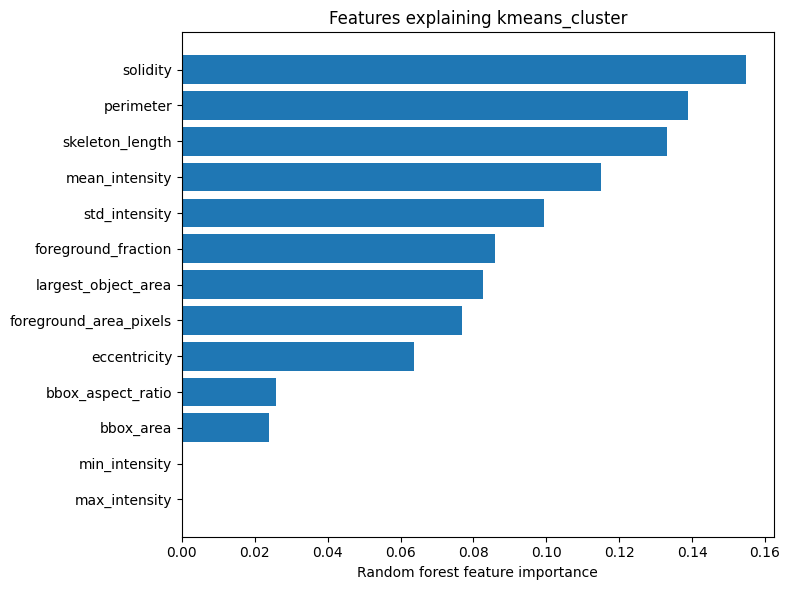

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_morphology_feature_importance.tiff


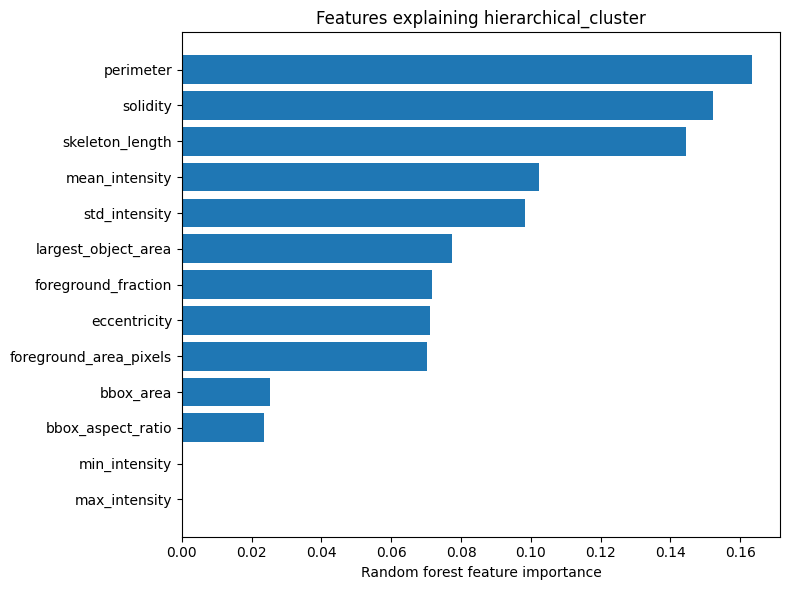

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_morphology_feature_importance.tiff


In [25]:
for cluster_col in cluster_cols:

    sub = importance_df[
        importance_df["cluster_method"] == cluster_col
    ].sort_values(
        "importance",
        ascending=True
    )

    fig = plt.figure(figsize=(8, 6))

    plt.barh(
        sub["feature"],
        sub["importance"]
    )

    plt.xlabel("Random forest feature importance")
    plt.title(f"Features explaining {cluster_col}")
    plt.tight_layout()

    out_path = fig_dir / f"rgc_{cluster_col}_morphology_feature_importance.tiff"
    fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", out_path)

## 8. KMeans stability across random seeds

This tests whether the KMeans grouping is robust to initialization.

High ARI across seeds suggests the grouping is stable. Low ARI suggests the clusters are unstable or poorly separated.

,seed,adjusted_rand_vs_original
count,100.0000,100.0000
mean,49.5000,0.8623
std,29.0115,0.1401
min,0.0000,0.4999
25%,24.7500,0.8839
50%,49.5000,0.9023
75%,74.2500,0.9226
max,99.0000,1.0000


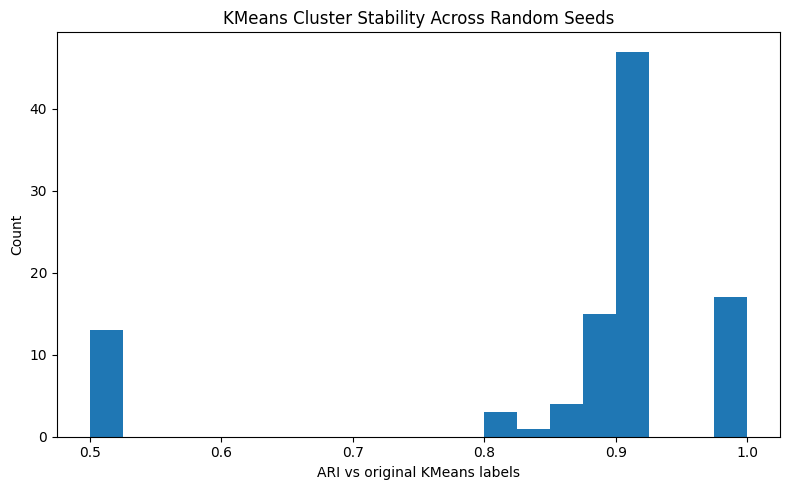

Saved:
../outputs/rgc_image_analysis/rgc_kmeans_seed_stability.csv
../outputs/rgc_image_analysis/figures/rgc_kmeans_seed_stability_histogram.tiff


In [26]:
kmeans_original = df["kmeans_cluster"].values
selected_k = len(np.unique(kmeans_original))

stability_rows = []

for seed in range(100):

    labels = KMeans(
        n_clusters=selected_k,
        random_state=seed,
        n_init=20
    ).fit_predict(X_pca) + 1

    ari = adjusted_rand_score(
        kmeans_original,
        labels
    )

    stability_rows.append({
        "seed": seed,
        "adjusted_rand_vs_original": ari
    })

stability_df = pd.DataFrame(stability_rows)

stability_path = output_dir / "rgc_kmeans_seed_stability.csv"
stability_df.to_csv(stability_path, index=False)

display(stability_df.describe().round(4))

fig = plt.figure(figsize=(8, 5))
plt.hist(
    stability_df["adjusted_rand_vs_original"],
    bins=20
)
plt.xlabel("ARI vs original KMeans labels")
plt.ylabel("Count")
plt.title("KMeans Cluster Stability Across Random Seeds")
plt.tight_layout()

out_path = fig_dir / "rgc_kmeans_seed_stability_histogram.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:")
print(stability_path)
print(out_path)

## 9. Manual interpretation table template

Fill this CSV manually after reviewing the cluster contact sheets.

Suggested annotations:
- dendritic field size
- branching density
- soma visibility
- radial symmetry
- elongation/asymmetry
- possible artifact
- candidate RGC subtype

In [27]:
manual_rows = []

for cluster_col in cluster_cols:

    for cluster in sorted(df[cluster_col].unique()):

        manual_rows.append({
            "cluster_method": cluster_col,
            "cluster": cluster,
            "manual_description": "",
            "dendritic_field_size": "",
            "branching_density": "",
            "soma_visibility": "",
            "radial_symmetry": "",
            "elongation_or_asymmetry": "",
            "artifact_or_quality_note": "",
            "candidate_biological_interpretation": ""
        })

manual_template = pd.DataFrame(manual_rows)

manual_path = output_dir / "rgc_manual_cluster_interpretation_template.csv"
manual_template.to_csv(manual_path, index=False)

display(manual_template)

print("Saved:", manual_path)

,cluster_method,cluster,manual_description,dendritic_field_size,branching_density,soma_visibility,radial_symmetry,elongation_or_asymmetry,artifact_or_quality_note,candidate_biological_interpretation
0,kmeans_cluster,1,,,,,,,,
1,kmeans_cluster,2,,,,,,,,
2,kmeans_cluster,3,,,,,,,,
3,kmeans_cluster,4,,,,,,,,
4,hierarchical_cluster,1,,,,,,,,
5,hierarchical_cluster,2,,,,,,,,
6,hierarchical_cluster,3,,,,,,,,
7,hierarchical_cluster,4,,,,,,,,


Saved: ../outputs/rgc_image_analysis/rgc_manual_cluster_interpretation_template.csv
